# Image Classification with Transfer Learning using DenseNet121
This notebook provides a practical, efficient approach to quickly train a high-performing image classifier without needing to train a deep CNN from scratch.

Demo For **binary image classification** (cats vs. dogs) using **transfer learning** with a pre-trained DenseNet121 model:

---

### **1. Data Preparation**
- Images are loaded from `train` and `test` directories using `ImageFolder`.
- Each image is resized, center-cropped to 224x224, and converted to a tensor.

### **2. Exploring Sample Images**
- A batch of training images is visualized to ensure proper loading and transformations.

### **3. Model Setup**
- A **pre-trained DenseNet121** is downloaded, which was originally trained on ImageNet.
- All existing model parameters are **frozen** to retain learned features.
- The **classifier (final layer)** is overwritten to:
  - Output **a single value** (for binary classification)
  - Apply a **Sigmoid activation** for probabilities between 0 and 1

### **4. Training**
- The model is trained **only on the new classifier** using the **Adam optimizer** and **binary cross-entropy loss**.
- Training runs for a fixed number of epochs, and the loss is tracked over time.

### **5. Evaluation**
- Predictions are made on the test set.
- Sample predictions are visualized with corresponding class labels.
- Model performance is quantified using **accuracy**.

### **Key Concepts Demonstrated**
- **Transfer Learning:** Leveraging pre-trained convolutional features for a new task.
- **Freezing Layers:** Training only the new classifier while keeping pre-trained weights fixed.
- **Binary Classification:** Using a single output with Sigmoid and BCELoss.
- **Visualization:** Displaying images and training loss to monitor performance.

Adapted from PyTorch Ultimate Course

In [1]:
from collections import OrderedDict 
import numpy as np 
import torch 
from torch import optim 
import torch.nn as nn 
import torchvision 
from torchvision import transforms,models 
import matplotlib.pyplot as plt 
import seaborn as sns
from sklearn.metrics import accuracy_score

In [2]:
def imshow(image_torch):
    # Make RGB
    image_torch = image_torch.numpy().transpose(1, 2, 0)
    plt.figure()
    plt.imshow(image_torch)

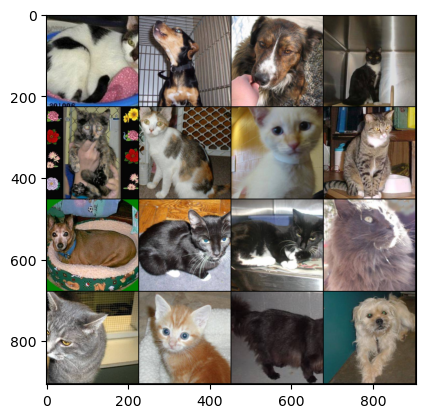

In [3]:
train_dir = 'train'
test_dir = 'test'

transform = transforms.Compose([transforms.Resize(255), 
                                transforms.CenterCrop(224), 
                                transforms.ToTensor()])

dataset = torchvision.datasets.ImageFolder(train_dir, transform=transform)
train_loader = torch.utils.data.DataLoader(dataset, batch_size=128, shuffle=True)

dataset = torchvision.datasets.ImageFolder(test_dir, transform=transform)
test_loader = torch.utils.data.DataLoader(dataset, batch_size=128, shuffle=True)

X_train, y_train = next(iter(train_loader))

image_grid = torchvision.utils.make_grid(X_train[:16, :, :, :], scale_each=True, nrow=4)

imshow(image_grid)


In [7]:
model = models.densenet121(pretrained=True)

# Freeze all the layers
for params in model.parameters():
    params.requires_grad = False

# Overwrite the classifier (originally trained for 1000 classes)
model.classifier = nn.Sequential(OrderedDict([ 
    ('fc1', nn.Linear(1024,1)),  # map features to 1 output
    ('Output', nn.Sigmoid())     # squash output to [0,1] for binary class
]))

optimizer = optim.Adam(model.classifier.parameters())
loss_function = nn.BCELoss()
train_losses = []

model.train()

NUM_EPOCHS = 100
for epoch in range(NUM_EPOCHS):
    train_loss = 0
    test_loss = 0
    for bat, (img, label) in enumerate(train_loader):

        optimizer.zero_grad()

        output = model(img)

        loss = loss_function(output.squeeze(), label.float())

        loss.backward()

        optimizer.step()

        train_loss += loss.item()

    train_losses.append(train_loss)
    if (epoch % 10 == 0):
        print(f"epoch: {epoch}: train loss {train_loss}")


epoch: 0: train loss 1.3727495670318604
epoch: 10: train loss 0.5101732015609741
epoch: 20: train loss 0.2953180819749832
epoch: 30: train loss 0.18929705768823624
epoch: 40: train loss 0.1563039794564247
epoch: 50: train loss 0.11740963160991669
epoch: 60: train loss 0.1443200334906578
epoch: 70: train loss 0.08947291597723961
epoch: 80: train loss 0.06930818036198616
epoch: 90: train loss 0.06262706406414509


Accuracy Score: 84.21 %


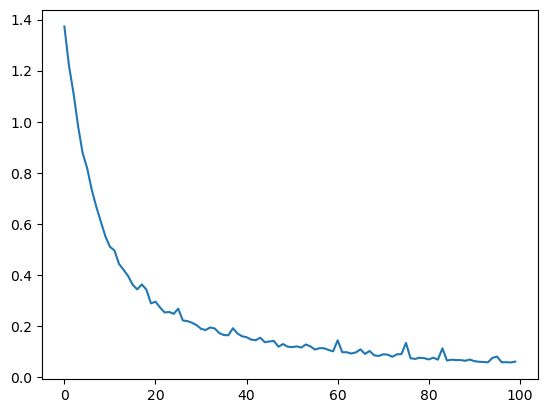

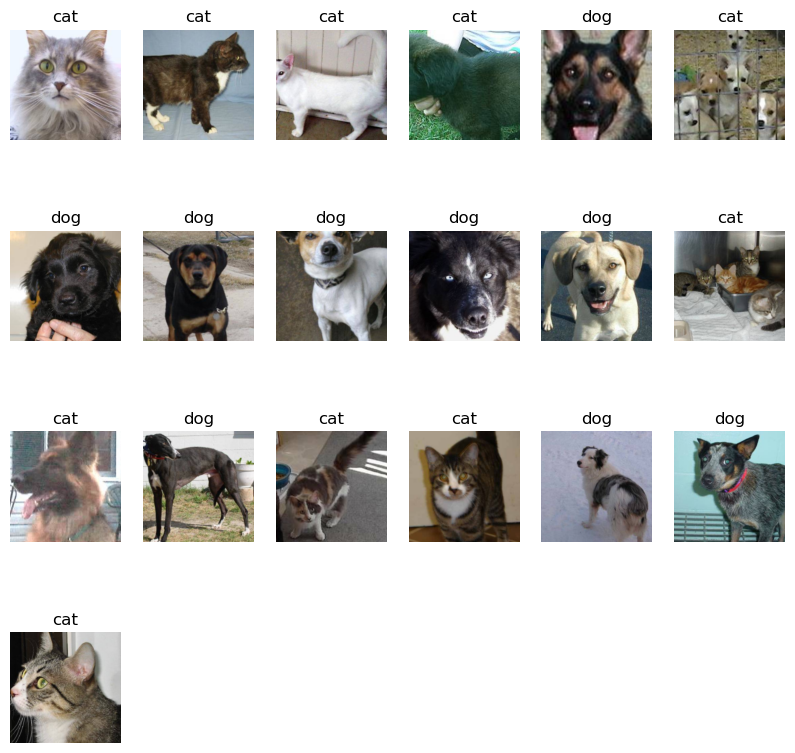

In [8]:
sns.lineplot(x=range(len(train_losses)), y=train_losses)

fig = plt.figure(figsize=(10, 10)) 
class_labels = {0:'cat', 1:'dog'} 
X_test, y_test = next(iter(test_loader))
with torch.no_grad():
    y_pred = model(X_test) 
    y_pred = y_pred.round()
    y_pred = [p.item() for p in y_pred] 

# Create subplots
for num, sample in enumerate(X_test): 
    plt.subplot(4,6,num+1) 
    plt.title(class_labels[y_pred[num]]) 
    plt.axis('off') 
    sample = sample.cpu().numpy() 
    plt.imshow(np.transpose(sample, (1,2,0))) 

# Accuracy
acc = accuracy_score(y_test, y_pred)
print(f"Accuracy Score: {np.round(acc * 100, 2)} %")
